In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("D:\Downloads\student_performance_ project\student_data.csv")



In [4]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 395
Number of columns: 33


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [7]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [18]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

In [9]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [10]:
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numerical_cols))

Numerical Columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [12]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(list(categorical_cols))

Categorical Columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


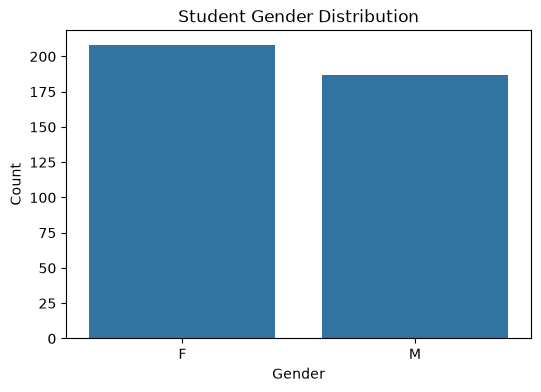

In [13]:
# Gender distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex")
plt.title("Student Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

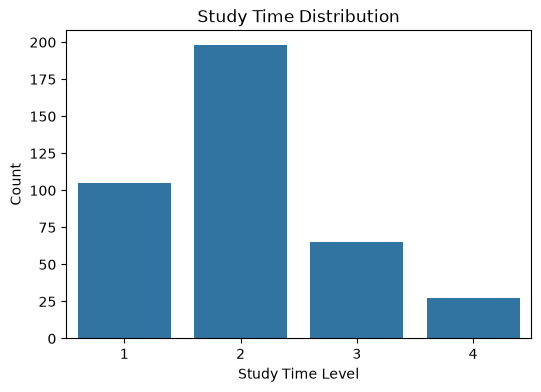

In [14]:
# Study time distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="studytime")
plt.title("Study Time Distribution")
plt.xlabel("Study Time Level")
plt.ylabel("Count")
plt.show()

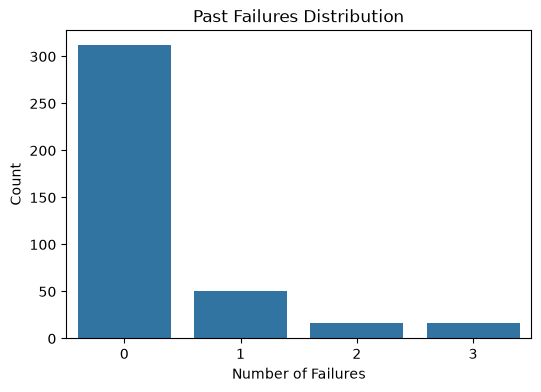

In [15]:
# Past failures distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="failures")
plt.title("Past Failures Distribution")
plt.xlabel("Number of Failures")
plt.ylabel("Count")
plt.show()

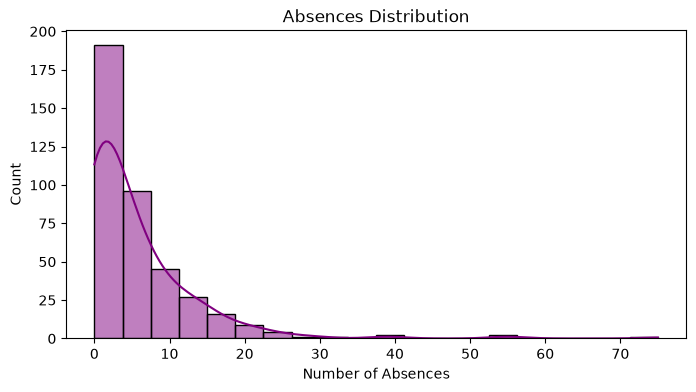

In [16]:
# Absences distribution plot
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="absences", bins=20, kde=True, color="purple")
plt.title("Absences Distribution")
plt.xlabel("Number of Absences")
plt.ylabel("Count")
plt.show()

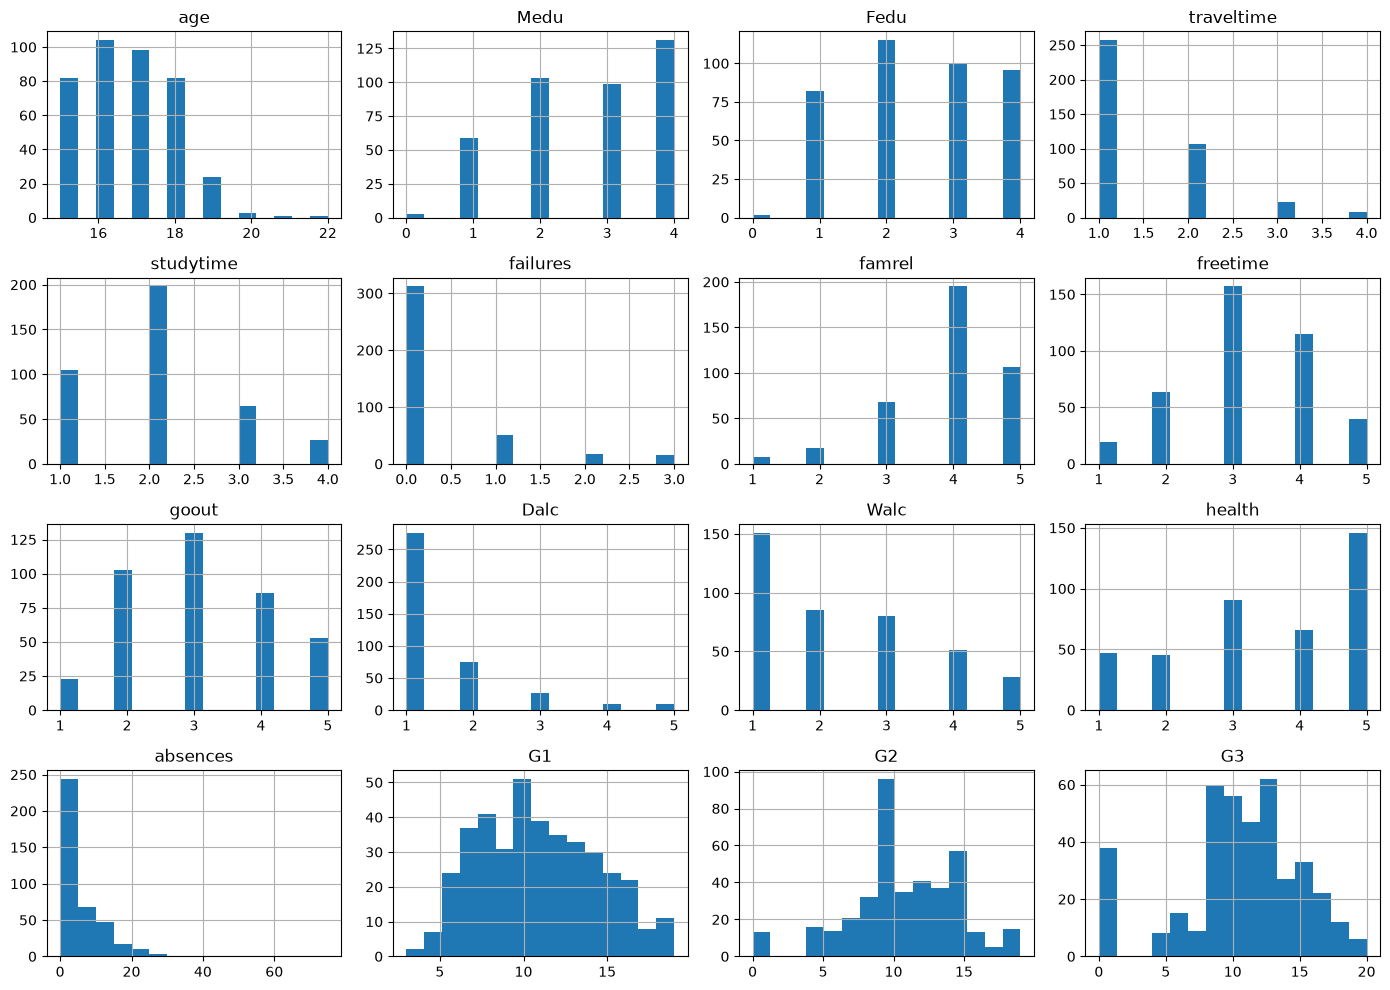

In [20]:
# Histograms for all numerical features
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(14, 10), bins=15)
plt.tight_layout()
plt.show()

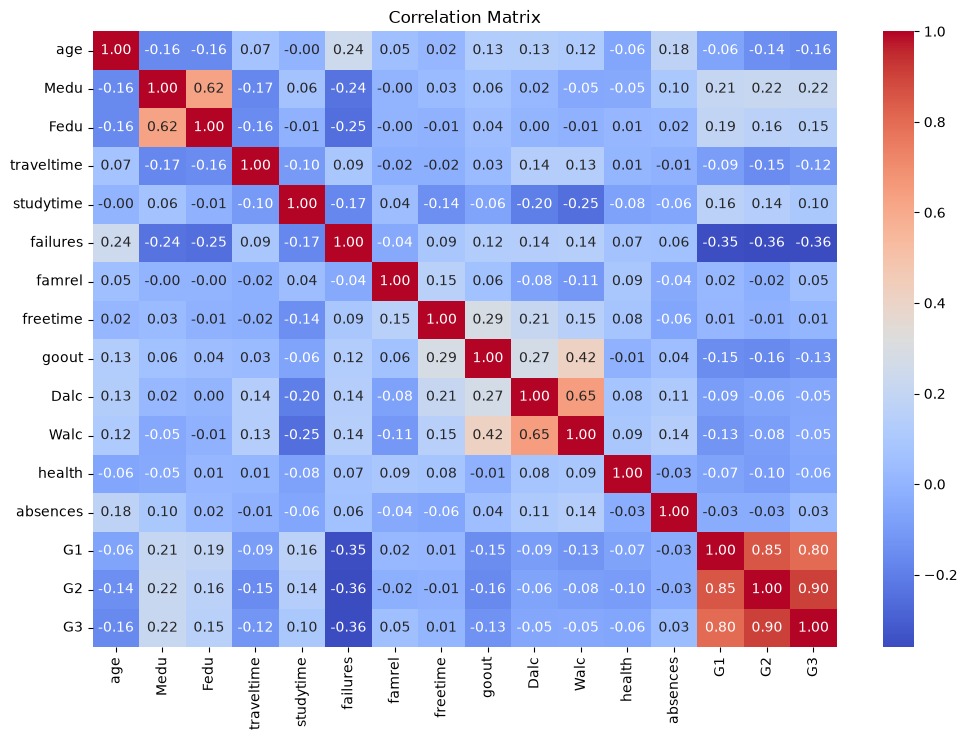

In [21]:
# Plot correlation matrix
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [22]:
# Calculate average score
df["Avg Score"] = df[["G1", "G2", "G3"]].mean(axis=1)

# Display head of grades columns
df[["G1", "G2", "G3", "Avg Score"]].head()

,G1,G2,G3,Avg Score
0,5,6,6,5.666667
1,5,5,6,5.333333
2,7,8,10,8.333333
3,15,14,15,14.666667
4,6,10,10,8.666667


In [23]:
# Divide scores into 3 equal performance categories
df["Performance Category"] = pd.qcut(
    df["Avg Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Display created target column
df[["Avg Score", "Performance Category"]].head()

,Avg Score,Performance Category
0,5.666667,Low
1,5.333333,Low
2,8.333333,Low
3,14.666667,High
4,8.666667,Low


Performance Category
Medium    136
Low       132
High      127
Name: count, dtype: int64


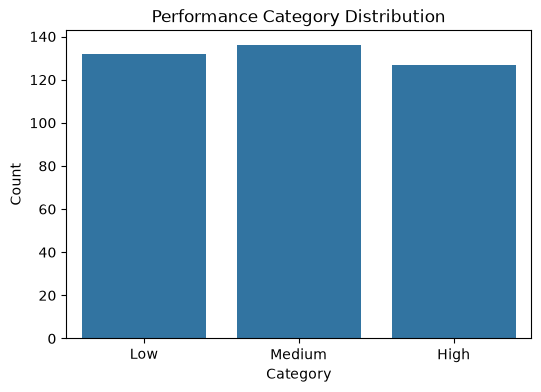

In [24]:
# Target value counts and countplot
print(df["Performance Category"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Performance Category")
plt.title("Performance Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [25]:
# Drop leakage columns
leakage_cols = ["G1", "G2", "G3", "Avg Score", "Performance Category"]
model_df = df.drop(columns=leakage_cols)

print("Remaining features count:", model_df.shape[1])

Remaining features count: 30


In [26]:
# Separate features and target
X = model_df.copy()
y = df["Performance Category"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 30)
y shape: (395,)


In [27]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 316
Testing samples: 79


In [28]:
# Identify feature column types
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features count:", len(num_features))
print("Categorical features count:", len(cat_features))

Numerical features count: 13
Categorical features count: 17


In [29]:
# Preprocessing for numerical and categorical data
num_transformer = Pipeline(steps=[("scaler", StandardScaler())])
cat_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

In [30]:
# Initialize classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf")
}

In [31]:
# Create combined pipeline per model
pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [32]:
# Train all models
trained_models = {}
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
KNN trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.


In [33]:
# Generate predictions on test data
predictions = {}
for name, model in trained_models.items():
    predictions[name] = model.predict(X_test)

In [34]:
# Calculate evaluation metrics
results = []
for name, y_pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1 Score": f1_score(y_test, y_pred, average="macro")
    })

# Convert to DataFrame and sort by F1 Score
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.493671,0.482493,0.496676,0.480135
1,Decision Tree,0.468354,0.473176,0.468661,0.468297
2,Random Forest,0.455696,0.465556,0.456790,0.460488
3,SVM,0.443038,0.490069,0.443020,0.454837
4,Logistic Regression,0.379747,0.383771,0.381292,0.381534


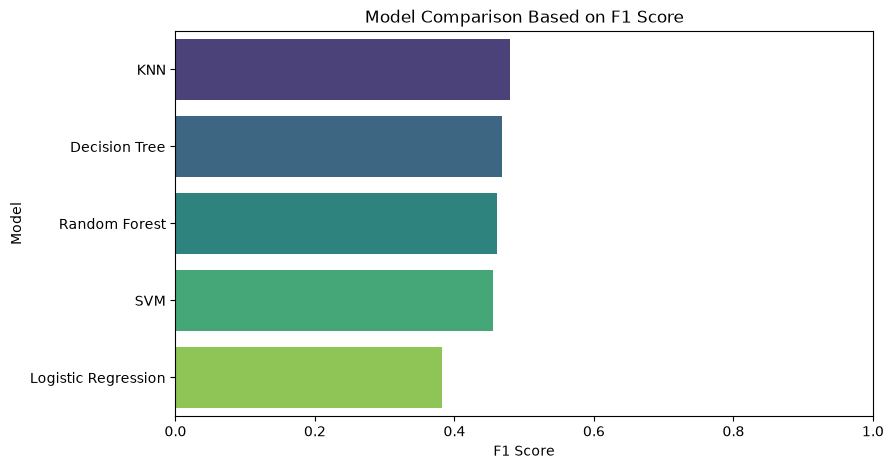

In [35]:
# Barplot model comparison
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="F1 Score", y="Model", palette="viridis")
plt.title("Model Comparison Based on F1 Score")
plt.xlim(0, 1)
plt.show()

In [36]:
# Setup stratified cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate cross validation scores
cv_results = []
for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="f1_macro")
    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

# Convert CV results to DataFrame
cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean CV F1", ascending=False).reset_index(drop=True)
cv_results_df

,Model,Mean CV F1,Std CV F1
0,Random Forest,0.489344,0.057065
1,Logistic Regression,0.464049,0.054341
2,KNN,0.444457,0.027415
3,SVM,0.442505,0.042461
4,Decision Tree,0.438963,0.070825


In [37]:
# Select best model based on CV F1 score
best_model_name = cv_results_df.loc[0, "Model"]
best_pipeline = pipelines[best_model_name]

# Retrain best pipeline on full dataset
best_pipeline.fit(X, y)

print("Best selected model:", best_model_name)

Best selected model: Random Forest


In [38]:
# Print detailed classification report
best_pred = best_pipeline.predict(X_test)
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        26
         Low       1.00      1.00      1.00        26
      Medium       1.00      1.00      1.00        27

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



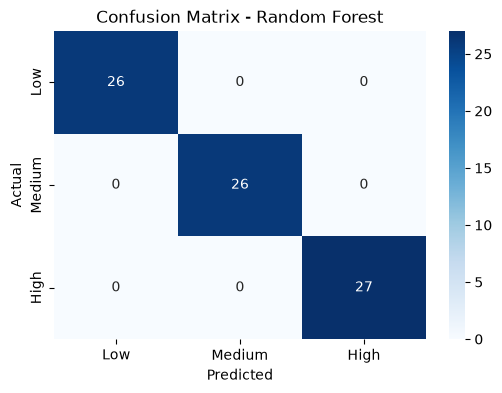

In [39]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
# Save best model to file
joblib.dump(best_pipeline, "best_student_model.pkl")
print("Model saved successfully as best_student_model.pkl")

Model saved successfully as best_student_model.pkl


In [42]:
# Load saved model and make a sample prediction
loaded_model = joblib.load("best_student_model.pkl")

sample_student = X.iloc[[0]]
prediction = loaded_model.predict(sample_student)

print("Predicted performance for sample student:", prediction[0])

Predicted performance for sample student: Low
